In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [201]:
df=pd.read_csv('online_retail_dataset.csv')

In [204]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Discount,PaymentMethod,ShippingCost,Category,SalesChannel,ReturnStatus,ShipmentProvider,WarehouseLocation,OrderPriority
0,221958,SKU_1964,White Mug,38,2020-01-01 00:00,1.71,37039.0,Australia,0.470000,Bank Transfer,10.79,Apparel,In-store,Not Returned,UPS,London,Medium
1,771155,SKU_1241,White Mug,18,2020-01-01 01:00,41.25,19144.0,Spain,0.190000,paypall,9.51,Electronics,Online,Not Returned,UPS,Rome,Medium
2,231932,SKU_1501,Headphones,49,2020-01-01 02:00,29.11,50472.0,Germany,0.350000,Bank Transfer,23.03,Electronics,Online,Returned,UPS,Berlin,High
3,465838,SKU_1760,Desk Lamp,14,2020-01-01 03:00,76.68,96586.0,Netherlands,0.140000,paypall,11.08,Accessories,Online,Not Returned,Royal Mail,Rome,Low
4,359178,SKU_1386,USB Cable,-30,2020-01-01 04:00,-68.11,NaN,United Kingdom,1.501433,Bank Transfer,NaN,Electronics,In-store,Not Returned,FedEx,NaN,Medium


In [153]:
df.shape

(49782, 17)

In [154]:
df.isnull().sum()

InvoiceNo               0
StockCode               0
Description             0
Quantity                0
InvoiceDate             0
UnitPrice               0
CustomerID           4978
Country                 0
Discount                0
PaymentMethod           0
ShippingCost         2489
Category                0
SalesChannel            0
ReturnStatus            0
ShipmentProvider        0
WarehouseLocation    3485
OrderPriority           0
dtype: int64

# droping null customer ids

In [155]:
df = df.dropna(subset=['CustomerID'])


# fill the null CustomerID as unknown

In [156]:
df['CustomerID'].fillna('unknown',inplace=True)

C:\Users\Hp\AppData\Local\Temp\ipykernel_11936\798473971.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CustomerID'].fillna('unknown',inplace=True)


In [157]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Discount', 'PaymentMethod',
       'ShippingCost', 'Category', 'SalesChannel', 'ReturnStatus',
       'ShipmentProvider', 'WarehouseLocation', 'OrderPriority'],
      dtype='object')

# creating new important columns

# Feature engineering 

In [158]:
df['TotalSales'] = df['Quantity'] * df['UnitPrice']

In [159]:
 df['FinalPrice'] = df['TotalSales'] - (df['TotalSales'] * df['Discount'])

# statistics summary

In [160]:
df.describe()

,InvoiceNo,Quantity,UnitPrice,CustomerID,Discount,ShippingCost,TotalSales,FinalPrice
count,44804.000000,44804.000000,44804.000000,44804.000000,44804.000000,44804.000000,44804.000000,44804.000000
mean,549849.692282,24.896973,50.622735,55032.871775,0.250474,17.484206,1258.846198,944.451383
std,260681.031778,14.150006,28.596901,25913.660157,0.144349,7.218483,1088.377301,852.195045
min,100005.000000,1.000000,1.000000,10001.000000,0.000000,5.000000,1.010000,0.717100
25%,323744.750000,13.000000,25.880000,32750.750000,0.130000,11.210000,358.555000,259.941975
50%,551099.500000,25.000000,50.490000,55165.000000,0.250000,17.470000,949.380000,691.980800
75%,775251.750000,37.000000,75.400000,77306.250000,0.380000,23.710000,1903.972500,1404.011400
max,999997.000000,49.000000,100.000000,99998.000000,0.500000,30.000000,4889.220000,4709.835900


# filling the null value as mean in  ShippingCost

In [161]:
shipping_cost_mean = df['ShippingCost'].mean()
df['ShippingCost'] = df['ShippingCost'].fillna(shipping_cost_mean)

In [162]:
df['NetRevenue'] = df['FinalPrice'] - df['ShippingCost']

In [163]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'] )

In [164]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month_name()
df['Day'] = df['InvoiceDate'].dt.day_name()

In [165]:
 

df['CustomerID'] = pd.to_numeric(df['CustomerID'], errors='coerce').astype('Int64')

In [166]:
total_customer=df['CustomerID'].nunique()
print(f'total_customer are:{total_customer}')

total_customer are:35389


In [167]:
df['WarehouseLocation'].unique()

array(['London', 'Rome', 'Berlin', 'Amsterdam', 'Paris'], dtype=object)

# filling  WarehouseLocation are NaN as Unknown location

In [168]:
df['WarehouseLocation'] = df['WarehouseLocation'].fillna('Unknown')

In [169]:
print(f'min:{df['NetRevenue'].min()}')
print(f'max :{df['NetRevenue'].max()}')


min:-28.3592
max :4703.4559


In [170]:
Total_Revenue=df['FinalPrice'].sum()
Total_Revenue

np.float64(42315199.7491)

In [171]:
df.isnull().sum()

InvoiceNo            0
StockCode            0
Description          0
Quantity             0
InvoiceDate          0
UnitPrice            0
CustomerID           0
Country              0
Discount             0
PaymentMethod        0
ShippingCost         0
Category             0
SalesChannel         0
ReturnStatus         0
ShipmentProvider     0
WarehouseLocation    0
OrderPriority        0
TotalSales           0
FinalPrice           0
NetRevenue           0
Year                 0
Month                0
Day                  0
dtype: int64

In [172]:
df.duplicated().sum()

np.int64(0)

In [173]:
df[df.duplicated()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Discount,PaymentMethod,...,ReturnStatus,ShipmentProvider,WarehouseLocation,OrderPriority,TotalSales,FinalPrice,NetRevenue,Year,Month,Day


In [174]:
df = df.drop_duplicates()

# Statical summary

In [175]:
df.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,Discount,ShippingCost,TotalSales,FinalPrice,NetRevenue,Year
count,44804.000000,44804.000000,44804,44804.000000,44804.0,44804.000000,44804.000000,44804.000000,44804.000000,44804.000000,44804.000000
mean,549849.692282,24.896973,2022-11-01 02:33:43.051513344,50.622735,55032.871775,0.250474,17.484206,1258.846198,944.451383,926.967176,2022.352357
min,100005.000000,1.000000,2020-01-01 00:00:00,1.000000,10001.0,0.000000,5.000000,1.010000,0.717100,-28.359200,2020.000000
25%,323744.750000,13.000000,2021-05-31 00:45:00,25.880000,32750.75,0.130000,11.210000,358.555000,259.941975,242.865975,2021.000000
50%,551099.500000,25.000000,2022-10-30 10:30:00,50.490000,55165.0,0.250000,17.470000,949.380000,691.980800,674.966200,2022.000000
75%,775251.750000,37.000000,2024-04-03 15:15:00,75.400000,77306.25,0.380000,23.710000,1903.972500,1404.011400,1387.146000,2024.000000
max,999997.000000,49.000000,2025-09-05 05:00:00,100.000000,99998.0,0.500000,30.000000,4889.220000,4709.835900,4703.455900,2025.000000
std,260681.031778,14.150006,NaN,28.596901,25913.660157,0.144349,7.218483,1088.377301,852.195045,852.214486,1.645572


In [176]:
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()
customer_orders[customer_orders > 1]

CustomerID
10005    2
10010    2
10020    2
10023    2
10045    2
        ..
99943    2
99965    2
99980    2
99986    2
99998    2
Name: InvoiceNo, Length: 8013, dtype: int64

In [177]:
customer_id = int(input("Enter the CustomerID: "))

orders = df[df['CustomerID'] == customer_id]

print("Total rows:", len(orders))
print("Total unique orders:", orders['InvoiceNo'].nunique())

orders

Enter the CustomerID:  33


Total rows: 0
Total unique orders: 0


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Discount,PaymentMethod,...,ReturnStatus,ShipmentProvider,WarehouseLocation,OrderPriority,TotalSales,FinalPrice,NetRevenue,Year,Month,Day


In [181]:
sales_2025 = df[df['Year'] == 2025]
monthly_sales_2025 = sales_2025.groupby('Month')['NetRevenue'].sum().reset_index()

print(monthly_sales_2025)

       Month   NetRevenue
0      April  611276.2137
1     August  650197.0551
2   February  570222.9180
3    January  631351.8547
4       July  602812.4875
5       June  582128.5246
6      March  633968.6743
7        May  612956.3823
8  September   83387.7261


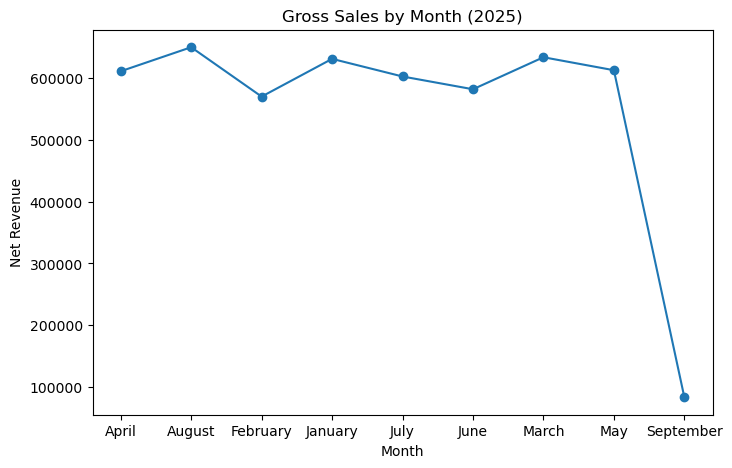

In [182]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(monthly_sales_2025['Month'], monthly_sales_2025['NetRevenue'], marker='o')

plt.title('Gross Sales by Month (2025)')
plt.xlabel('Month')
plt.ylabel('Net Revenue')
plt.show()

In [183]:
 
# Only numeric columns
numeric_df = df.select_dtypes(include=['int64','float64'])

# Correlation matrix
corr_matrix = numeric_df.corr()
corr_matrix

,InvoiceNo,Quantity,UnitPrice,CustomerID,Discount,ShippingCost,TotalSales,FinalPrice,NetRevenue
InvoiceNo,1.000000,0.007537,-0.013234,0.000730,-0.000147,0.001501,-0.005305,-0.005382,-0.005395
Quantity,0.007537,1.000000,-0.003724,0.002889,-0.000625,-0.004307,0.656682,0.629526,0.629548
UnitPrice,-0.013234,-0.003724,1.000000,0.000065,-0.005517,0.004842,0.653457,0.626960,0.626904
CustomerID,0.000730,0.002889,0.000065,1.000000,0.010822,0.004071,0.001311,-0.001080,-0.001114
Discount,-0.000147,-0.000625,-0.005517,0.010822,1.000000,-0.003891,-0.005811,-0.219464,-0.219426
ShippingCost,0.001501,-0.004307,0.004842,0.004071,-0.003891,1.000000,-0.000669,0.001542,-0.006928
TotalSales,-0.005305,0.656682,0.653457,0.001311,-0.005811,-0.000669,1.000000,0.959147,0.959131
FinalPrice,-0.005382,0.629526,0.626960,-0.001080,-0.219464,0.001542,0.959147,1.000000,0.999964
NetRevenue,-0.005395,0.629548,0.626904,-0.001114,-0.219426,-0.006928,0.959131,0.999964,1.000000


### This heatmap shows the correlation between numeric variables.
### Blue means strong positive correlation, red means negative.
### For example, Quantity and FinalPrice are strongly positively correlated — more items sold leads to higher revenue.

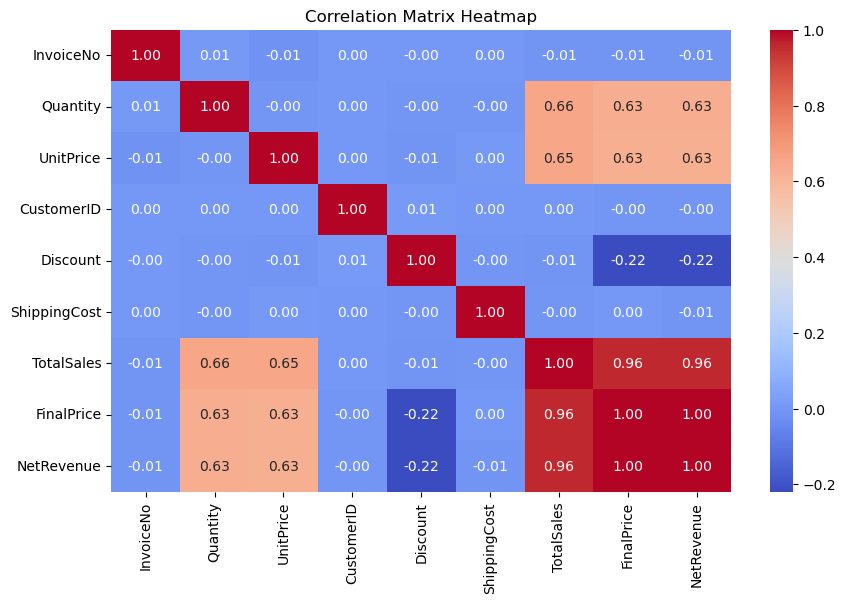

In [184]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

In [185]:
# top selling product
top_selling=df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

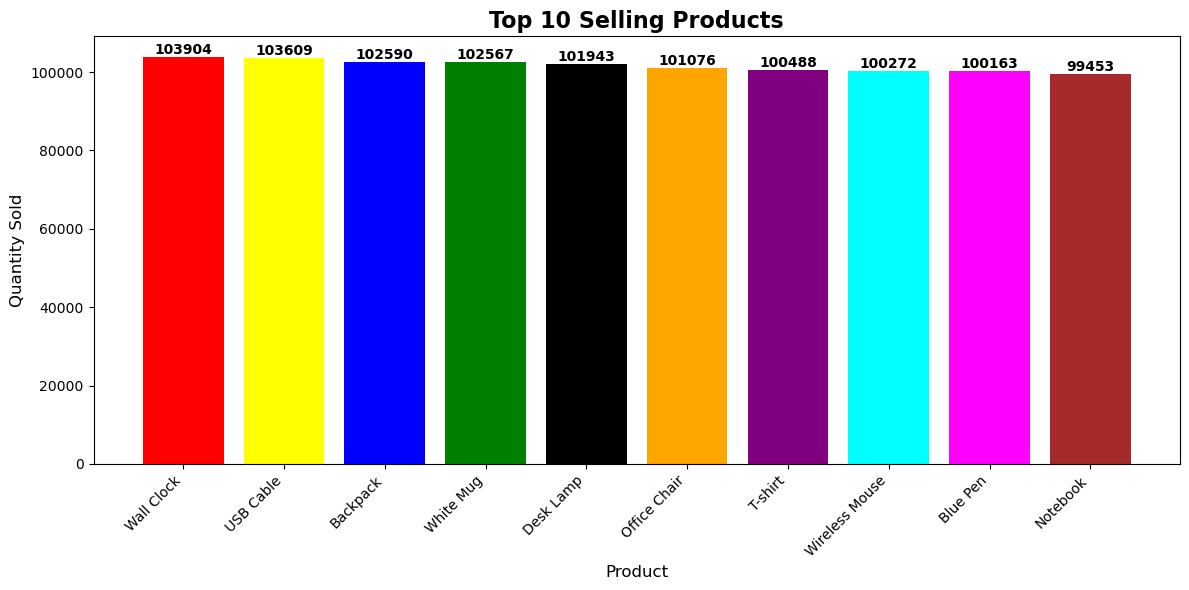

In [186]:
plt.figure(figsize=(12,6))

colors = ['red','yellow','blue','green','black','orange','purple','cyan','magenta','brown']
bars = plt.bar(top_selling.index, top_selling.values, color=colors)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontweight='bold')


plt.title('Top 10 Selling Products', fontsize=16, fontweight='bold')
plt.xlabel('Product', fontsize=12)
plt.ylabel('Quantity Sold', fontsize=12)
plt.xticks(rotation=45, ha='right')  
plt.tight_layout()
plt.show()

 # monthly revenue of all years 

In [187]:
monthly_sales = df.groupby('Month')['FinalPrice'].sum().reset_index()
monthly_sales
monthly_sales['FinalPrice_formatted'] = monthly_sales['FinalPrice'].apply(lambda x: f"${x:,.2f}")
monthly_sales

,Month,FinalPrice,FinalPrice_formatted
0,April,3.704115e+06,"$3,704,114.64"
1,August,3.810195e+06,"$3,810,194.85"
2,December,3.145271e+06,"$3,145,271.23"
3,February,3.472194e+06,"$3,472,193.86"
4,January,3.809589e+06,"$3,809,589.15"
5,July,3.722375e+06,"$3,722,374.61"
6,June,3.645877e+06,"$3,645,877.42"
7,March,3.836896e+06,"$3,836,896.20"
8,May,3.734436e+06,"$3,734,436.08"
9,November,3.115582e+06,"$3,115,581.83"


C:\Users\Hp\AppData\Local\Temp\ipykernel_11936\580511009.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='FinalPrice', data=monthly_sales, palette=colors)
C:\Users\Hp\AppData\Local\Temp\ipykernel_11936\580511009.py:3: UserWarning: 
The palette list has fewer values (10) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x='Month', y='FinalPrice', data=monthly_sales, palette=colors)


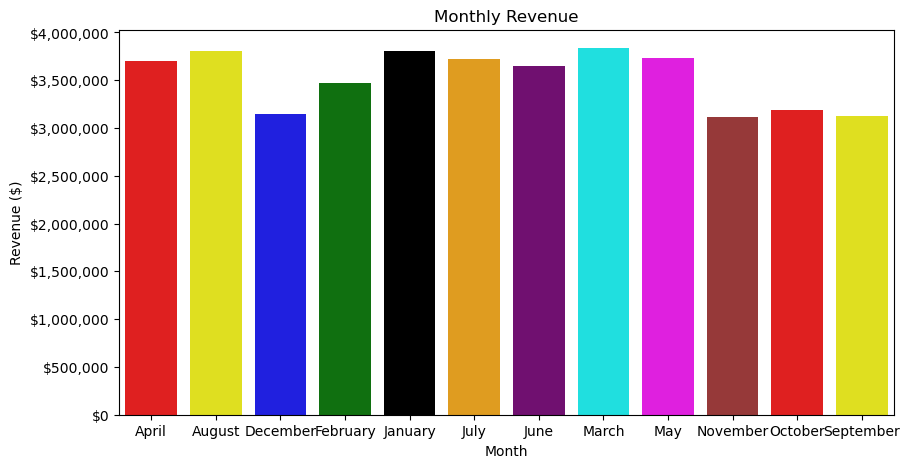

In [188]:
colors = ['red','yellow','blue','green','black','orange','purple','cyan','magenta','brown']
plt.figure(figsize=(10,5))
sns.barplot(x='Month', y='FinalPrice', data=monthly_sales, palette=colors)
plt.ylabel('Revenue ($)')
plt.xlabel('Month')
plt.title('Monthly Revenue')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"${y:,.0f}"))  # format y-axis as $ 
plt.show()

# highest revenue products:

In [189]:
top_products = df.groupby('Description')['FinalPrice'].sum() \
                 .sort_values(ascending=False) \
                 .head(10) \
                 .reset_index()
top_products
top_products['FinalPrice_formatted'] = top_products['FinalPrice'].apply(lambda x: f"${x:,.2f}")
top_products

,Description,FinalPrice,FinalPrice_formatted
0,White Mug,3.950316e+06,"$3,950,316.26"
1,Wall Clock,3.894783e+06,"$3,894,783.09"
2,Desk Lamp,3.890642e+06,"$3,890,642.47"
3,USB Cable,3.883872e+06,"$3,883,871.56"
4,Backpack,3.859457e+06,"$3,859,457.36"
5,Blue Pen,3.822014e+06,"$3,822,013.80"
6,Headphones,3.818923e+06,"$3,818,923.07"
7,Wireless Mouse,3.807658e+06,"$3,807,658.36"
8,T-shirt,3.802392e+06,"$3,802,392.37"
9,Notebook,3.802158e+06,"$3,802,158.06"


C:\Users\Hp\AppData\Local\Temp\ipykernel_11936\376164933.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Description', y='FinalPrice', data=top_products, palette='viridis')


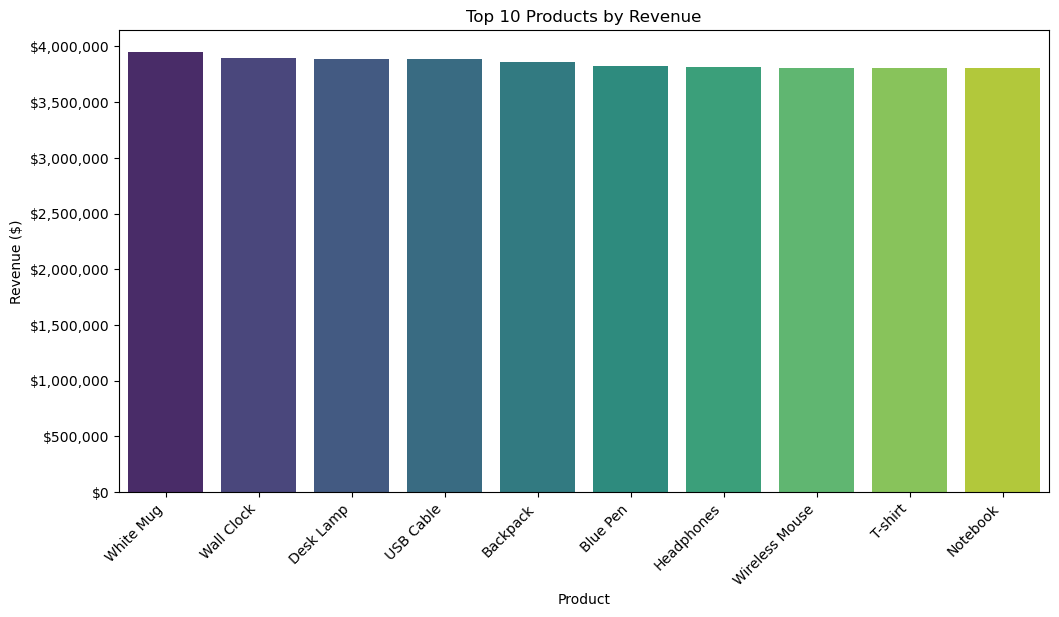

In [190]:
plt.figure(figsize=(12,6))
sns.barplot(x='Description', y='FinalPrice', data=top_products, palette='viridis')
plt.ylabel('Revenue ($)')
plt.xlabel('Product')
plt.title('Top 10 Products by Revenue')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"${y:,.0f}"))
plt.xticks(rotation=45, ha='right')  # rotate product names so they fit
plt.show()

# product category generates the most revenue.

In [191]:
category_revenue = df.groupby('Category')['FinalPrice'].sum().sort_values(ascending=False).reset_index() 
 

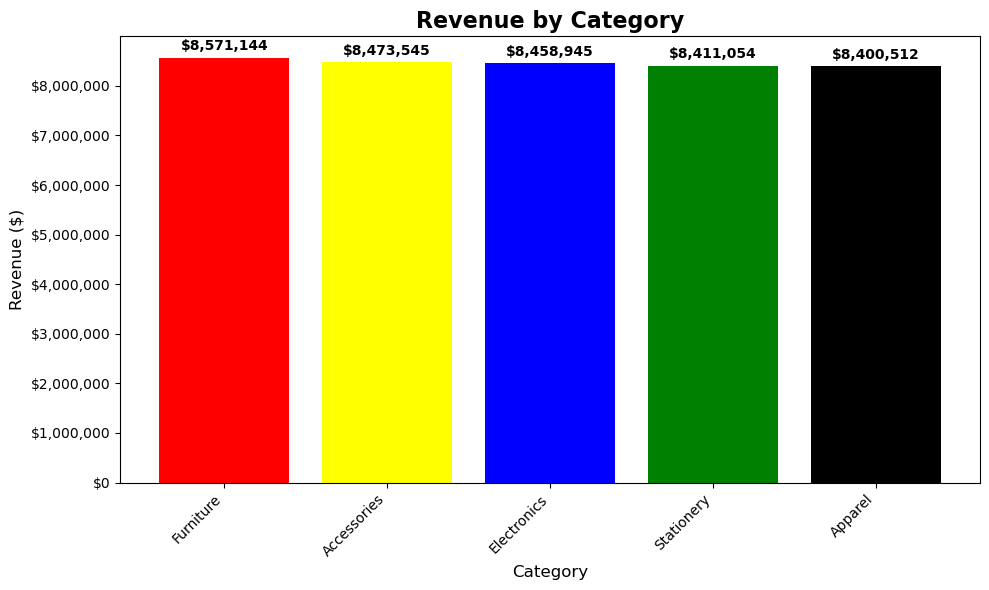

In [192]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10,6))

bars = plt.bar(category_revenue['Category'], category_revenue['FinalPrice'], color=['red','yellow','blue','green','black'])
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"${y:,.0f}"))
# Add value top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01*yval, f"${yval:,.0f}", ha='center', va='bottom', fontweight='bold')

# Titles and labels
plt.title('Revenue by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# country sales analysis

In [193]:
result = df.groupby('Country')['FinalPrice'].sum().sort_values(ascending=False).reset_index()
result['FinalPrice'] = result['FinalPrice'].map('${:,.2f}'.format)
result

,Country,FinalPrice
0,Belgium,"$3,628,107.84"
1,United States,"$3,609,185.48"
2,France,"$3,577,957.99"
3,Sweden,"$3,555,066.18"
4,Germany,"$3,548,894.03"
5,United Kingdom,"$3,539,162.23"
6,Portugal,"$3,521,324.22"
7,Spain,"$3,512,489.73"
8,Norway,"$3,495,541.63"
9,Italy,"$3,478,254.08"


# top customer 

In [194]:
res=df.groupby('CustomerID')['FinalPrice'].sum().sort_values(ascending=False).head(10).reset_index()
res['FinalPrice']=res['FinalPrice'].map('${:,.2f}'.format)
res

,CustomerID,FinalPrice
0,84431,"$9,777.49"
1,81067,"$9,678.65"
2,81631,"$8,690.41"
3,98923,"$8,655.47"
4,80001,"$8,547.84"
5,76402,"$8,235.68"
6,29700,"$8,033.66"
7,72172,"$7,874.69"
8,52808,"$7,843.39"
9,26371,"$7,723.45"


# most use payment metjhod

In [195]:
df['PaymentMethod'].value_counts().reset_index()

,PaymentMethod,count
0,Bank Transfer,15086
1,Credit Card,14907
2,paypall,14811


# selling channels 

In [196]:
ress=df.groupby('SalesChannel')['FinalPrice'].sum().reset_index()
ress['FinalPrice']=ress['FinalPrice'].map('${:,.2f}'.format)
ress

,SalesChannel,FinalPrice
0,In-store,"$21,095,902.96"
1,Online,"$21,219,296.79"


In [197]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Discount,PaymentMethod,...,ReturnStatus,ShipmentProvider,WarehouseLocation,OrderPriority,TotalSales,FinalPrice,NetRevenue,Year,Month,Day
0,221958,SKU_1964,White Mug,38,2020-01-01 00:00:00,1.71,37039,Australia,0.47,Bank Transfer,...,Not Returned,UPS,London,Medium,64.98,34.4394,23.6494,2020,January,Wednesday
1,771155,SKU_1241,White Mug,18,2020-01-01 01:00:00,41.25,19144,Spain,0.19,paypall,...,Not Returned,UPS,Rome,Medium,742.50,601.4250,591.9150,2020,January,Wednesday
2,231932,SKU_1501,Headphones,49,2020-01-01 02:00:00,29.11,50472,Germany,0.35,Bank Transfer,...,Returned,UPS,Berlin,High,1426.39,927.1535,904.1235,2020,January,Wednesday
3,465838,SKU_1760,Desk Lamp,14,2020-01-01 03:00:00,76.68,96586,Netherlands,0.14,paypall,...,Not Returned,Royal Mail,Rome,Low,1073.52,923.2272,912.1472,2020,January,Wednesday
5,744167,SKU_1006,Office Chair,47,2020-01-01 05:00:00,70.16,53887,Sweden,0.48,Credit Card,...,Not Returned,DHL,London,Medium,3297.52,1714.7104,1700.7304,2020,January,Wednesday


In [198]:
df.to_csv('online_retail_cleaned.csv', index=False)

In [199]:
dd=pd.read_csv('online_retail_cleaned.csv')
dd

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Discount,PaymentMethod,...,ReturnStatus,ShipmentProvider,WarehouseLocation,OrderPriority,TotalSales,FinalPrice,NetRevenue,Year,Month,Day
0,221958,SKU_1964,White Mug,38,2020-01-01 00:00:00,1.71,37039,Australia,0.47,Bank Transfer,...,Not Returned,UPS,London,Medium,64.98,34.4394,23.6494,2020,January,Wednesday
1,771155,SKU_1241,White Mug,18,2020-01-01 01:00:00,41.25,19144,Spain,0.19,paypall,...,Not Returned,UPS,Rome,Medium,742.50,601.4250,591.9150,2020,January,Wednesday
2,231932,SKU_1501,Headphones,49,2020-01-01 02:00:00,29.11,50472,Germany,0.35,Bank Transfer,...,Returned,UPS,Berlin,High,1426.39,927.1535,904.1235,2020,January,Wednesday
3,465838,SKU_1760,Desk Lamp,14,2020-01-01 03:00:00,76.68,96586,Netherlands,0.14,paypall,...,Not Returned,Royal Mail,Rome,Low,1073.52,923.2272,912.1472,2020,January,Wednesday
4,744167,SKU_1006,Office Chair,47,2020-01-01 05:00:00,70.16,53887,Sweden,0.48,Credit Card,...,Not Returned,DHL,London,Medium,3297.52,1714.7104,1700.7304,2020,January,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44799,354083,SKU_1562,Blue Pen,25,2025-09-05 01:00:00,70.92,51445,Spain,0.20,Credit Card,...,Returned,UPS,Berlin,Medium,1773.00,1418.4000,1409.4400,2025,September,Friday
44800,296698,SKU_1930,USB Cable,7,2025-09-05 02:00:00,51.74,28879,United States,0.23,Bank Transfer,...,Not Returned,FedEx,Amsterdam,Low,362.18,278.8786,255.3286,2025,September,Friday
44801,177622,SKU_1766,Office Chair,43,2025-09-05 03:00:00,85.25,21825,Portugal,0.20,Bank Transfer,...,Not Returned,FedEx,London,High,3665.75,2932.6000,2916.3400,2025,September,Friday
44802,701213,SKU_1602,Notebook,48,2025-09-05 04:00:00,39.64,43199,United Kingdom,0.31,paypall,...,Not Returned,Royal Mail,London,Medium,1902.72,1312.8768,1284.3168,2025,September,Friday
